# Multi-Zone Queuing Network Simulation
This notebook imports the custom DES engine, configures the specific topology, runs the simulation, and visualizes bottlenecks.

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sim_engine as sim

# Set visualization style
sns.set_theme(style="whitegrid")

In [2]:
# 1. Initialize Engine & Ledger
env = sim.Environment()
ledger = sim.GeneralLedger()

# 2. Define Routing Logic for the Junction
def routing_logic(entity):
    if entity.properties.get("type") == "green_bound":
        return green_zone
    else:
        return hall_zone

# 3. Build Topology (Back to Front for upstream binding)

# Sink
sink = sim.Destroyer(env, "Sink", ledger)

# Rest Zone (Merges DC and Green, feeds Sink)
rest_zone = sim.BlockedZone(env, "Rest_Zone", ledger, num_servers=4, queue_capacity=10, 
                            service_time_func=lambda: random.expovariate(1.0), next_node=sink)

# DC Zone (feeds Rest)
dc_zone = sim.BlockedZone(env, "DC_Zone", ledger, num_servers=2, queue_capacity=5, 
                          service_time_func=lambda: random.uniform(2, 4), next_node=rest_zone)

# Overflow Zone (feeds DC)
overflow_zone = sim.BlockedZone(env, "Overflow_Zone", ledger, num_servers=3, queue_capacity=8, 
                                service_time_func=lambda: random.expovariate(0.5), next_node=dc_zone)

# Branch A: Hall Zone (feeds Overflow)
hall_zone = sim.BlockedZone(env, "Hall_Zone", ledger, num_servers=5, queue_capacity=10, 
                            service_time_func=lambda: random.normalvariate(3, 0.5), next_node=overflow_zone)

# Branch B: Green Zone (feeds Rest)
green_zone = sim.BlockedZone(env, "Green_Zone", ledger, num_servers=2, queue_capacity=5, 
                             service_time_func=lambda: random.uniform(1, 3), next_node=rest_zone)

# Junction
junction = sim.Junction(env, "Main_Junction", ledger, routing_func=routing_logic)
junction.connect_downstream(hall_zone)
junction.connect_downstream(green_zone)

# Buffer & Generator
buffer = sim.InfiniteBuffer(env, "Entry_Buffer", ledger, next_node=junction)

gen = sim.Generator(env, "Generator", ledger, 
                    interarrival_func=lambda: random.expovariate(2.5), 
                    entity_types=["hall_bound", "green_bound"],
                    type_weights=[0.7, 0.3],
                    next_node=buffer)

In [3]:
# 4. Run the Simulation
SIM_TIME = 200.0
print(f"Running simulation for {SIM_TIME} time units...")
env.run(until=SIM_TIME)

# Extract Data
df = ledger.to_dataframe()
print(f"Simulation complete. Logged {len(df)} events.")
display(df.head())

Running simulation for 200.0 time units...
Simulation complete. Logged 4378 events.


,time,entity_id,node,event
0,0.0,E1,Generator,created
1,0.0,E1,Entry_Buffer,buffered
2,0.0,E1,Entry_Buffer,released_from_buffer
3,0.0,E1,Main_Junction,routed
4,0.0,E1,Green_Zone,arrived


/var/folders/67/wzvsxh_n1v94fgn5gffprr4m0000gn/T/ipykernel_86395/1394755722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=blocked_counts.values, y=blocked_counts.index, ax=axes[0], palette="Reds_r")
/var/folders/67/wzvsxh_n1v94fgn5gffprr4m0000gn/T/ipykernel_86395/1394755722.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=queue_counts.values, y=queue_counts.index, ax=axes[1], palette="Blues_r")


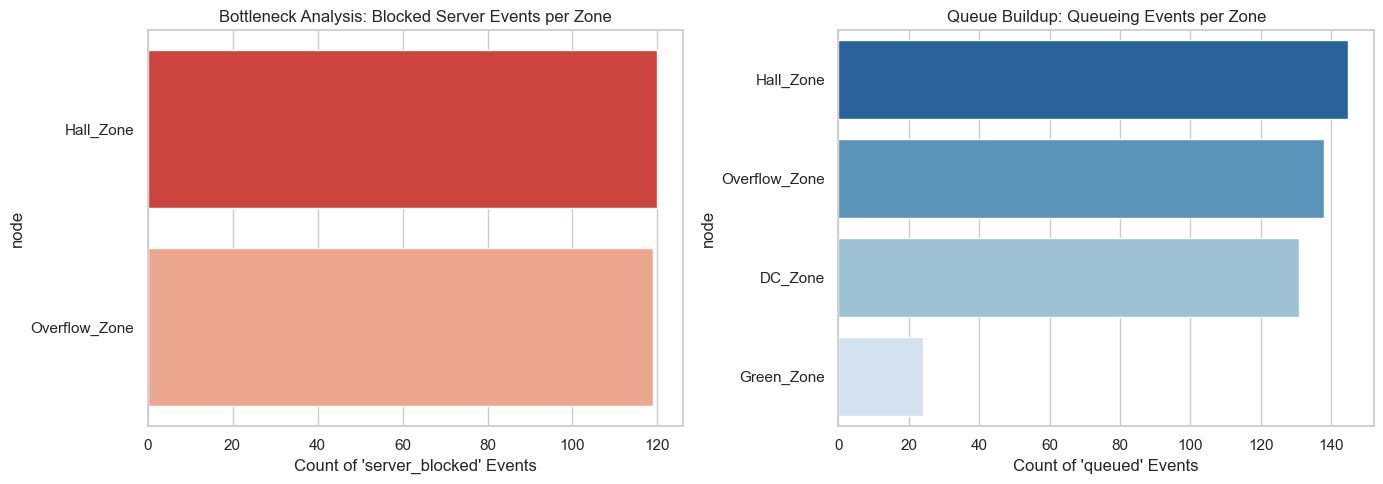

In [4]:
# 5. Visualize Bottlenecks (Blocked Servers & Queueing Events)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Where do servers spend the most time blocked?
blocked_counts = df[df['event'] == 'server_blocked']['node'].value_counts()
if not blocked_counts.empty:
    sns.barplot(x=blocked_counts.values, y=blocked_counts.index, ax=axes[0], palette="Reds_r")
    axes[0].set_title("Bottleneck Analysis: Blocked Server Events per Zone")
    axes[0].set_xlabel("Count of 'server_blocked' Events")
else:
    axes[0].text(0.5, 0.5, 'No Blocked Events', ha='center', va='center')
    axes[0].set_title("No Upstream Blocking Occurred")

# Plot 2: Where do entities queue the most?
queue_counts = df[df['event'] == 'queued']['node'].value_counts()
if not queue_counts.empty:
    sns.barplot(x=queue_counts.values, y=queue_counts.index, ax=axes[1], palette="Blues_r")
    axes[1].set_title("Queue Buildup: Queueing Events per Zone")
    axes[1].set_xlabel("Count of 'queued' Events")
else:
    axes[1].text(0.5, 0.5, 'No Queueing Events', ha='center', va='center')
    axes[1].set_title("No Queue Buildup Occurred")

plt.tight_layout()
plt.show()